# Visual Product Search Engine — Annotation BBox Cropping

This notebook crops all catalog images using the **ground truth bounding box annotations**
from `list_bbox_inshop.txt` instead of YOLO predictions.

---

### Why annotation bbox instead of YOLO?

The annotation bboxes are human-labelled ground truth — they are tight and accurate.
YOLO predictions can sometimes include extra clothing items in one crop.
Since annotations are available for all catalog images, we use them directly.

For the Streamlit demo, YOLO is still used since user-uploaded images have no annotations.

---

### Strategy (TA Option 1)
- Offline catalog (train/gallery/query) -> annotation bbox crop
- Online query in Streamlit -> fine-tuned YOLO crop

---

### Inputs
- `fashionvirtualsearchdataset` — raw images
- `preprocesseddatasetvr` — master_df.csv with annotation bboxes

### Outputs
- `data/bbox_crops/` — cropped images
- `master_crops.csv`, `train_crops.csv`, `query_crops.csv`, `gallery_crops.csv`

## Step 1: Import Libraries

In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import warnings
warnings.filterwarnings('ignore')

print('Libraries imported successfully!')

Libraries imported successfully!


## Step 2: Define Paths and Config

In [2]:
IMAGE_DIR = '/kaggle/input/datasets/harshitabansal307/fashionvirtualsearchdataset/dataset/img'
CSV_DIR   = '/kaggle/input/datasets/harshitabansal307/preprocesseddatasetvr'

OUTPUT_DIR = '/kaggle/working'
CROP_DIR   = os.path.join(OUTPUT_DIR, 'data', 'bbox_crops')
os.makedirs(CROP_DIR, exist_ok=True)

BBOX_PADDING = 10

for label, path in [('IMAGE_DIR', IMAGE_DIR), ('CSV_DIR', CSV_DIR)]:
    status = 'Found' if os.path.exists(path) else 'NOT FOUND'
    print(f'[{status}] {label}: {path}')

[Found] IMAGE_DIR: /kaggle/input/datasets/harshitabansal307/fashionvirtualsearchdataset/dataset/img
[Found] CSV_DIR: /kaggle/input/datasets/harshitabansal307/preprocesseddatasetvr


## Step 3: Load Master CSV

Load master_df.csv from preprocessing notebook.
It has image paths, split labels, clothes_type, and annotation bbox (x1,y1,x2,y2).

In [3]:
df = pd.read_csv(os.path.join(CSV_DIR, 'master_df.csv'))

print(f'Total rows : {len(df):,}')
print(f'Columns    : {df.columns.tolist()}')
print()
print('Split distribution:')
print(df['split'].value_counts().to_string())
print()
print('Clothes type distribution (1=upper, 2=lower, 3=full):')
print(df['clothes_type'].value_counts().sort_index().to_string())
print()
df.head()

Total rows : 52,712
Columns    : ['image_name', 'item_id', 'split', 'clothes_type', 'pose_type', 'x1', 'y1', 'x2', 'y2']

Split distribution:
split
train      25882
query      14218
gallery    12612

Clothes type distribution (1=upper, 2=lower, 3=full):
clothes_type
1    33487
2    10494
3     8731



,image_name,item_id,split,clothes_type,pose_type,x1,y1,x2,y2
0,img/WOMEN/Dresses/id_00000002/02_1_front.jpg,id_00000002,train,3,1,65,45,233,252
1,img/WOMEN/Dresses/id_00000002/02_2_side.jpg,id_00000002,train,3,2,112,41,168,247
2,img/WOMEN/Dresses/id_00000002/02_4_full.jpg,id_00000002,train,3,4,89,34,169,167
3,img/WOMEN/Dresses/id_00000002/02_7_additional.jpg,id_00000002,train,3,5,73,40,194,251
4,img/WOMEN/Skirts/id_00000003/02_1_front.jpg,id_00000003,train,2,1,51,122,160,210


## Step 4: Define Helper Functions

In [4]:
def get_full_path(image_name):
    relative = image_name[4:] if image_name.startswith('img/') else image_name
    return os.path.join(IMAGE_DIR, relative)


def get_crop_save_path(image_name):
    relative = image_name[4:] if image_name.startswith('img/') else image_name
    return os.path.join(CROP_DIR, relative)


def crop_and_save(img, x1, y1, x2, y2, save_path, padding=BBOX_PADDING):
    W, H = img.size
    x1 = max(0, int(x1) - padding)
    y1 = max(0, int(y1) - padding)
    x2 = min(W, int(x2) + padding)
    y2 = min(H, int(y2) + padding)
    cropped = img.crop((x1, y1, x2, y2))
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    cropped.save(save_path, quality=95)
    return cropped


# Test on first row
row      = df.iloc[0]
src_path = get_full_path(row['image_name'])
print(f'Sample image_name : {row["image_name"]}')
print(f'Source path       : {src_path}')
print(f'Exists            : {os.path.exists(src_path)}')
print(f'Bbox              : x1={row["x1"]} y1={row["y1"]} x2={row["x2"]} y2={row["y2"]}')

Sample image_name : img/WOMEN/Dresses/id_00000002/02_1_front.jpg
Source path       : /kaggle/input/datasets/harshitabansal307/fashionvirtualsearchdataset/dataset/img/WOMEN/Dresses/id_00000002/02_1_front.jpg
Exists            : True
Bbox              : x1=65 y1=45 x2=233 y2=252


## Step 5: Visualise Annotation Bboxes Before Cropping

Draw annotation bboxes on sample images to verify they are tight around just the clothing item.

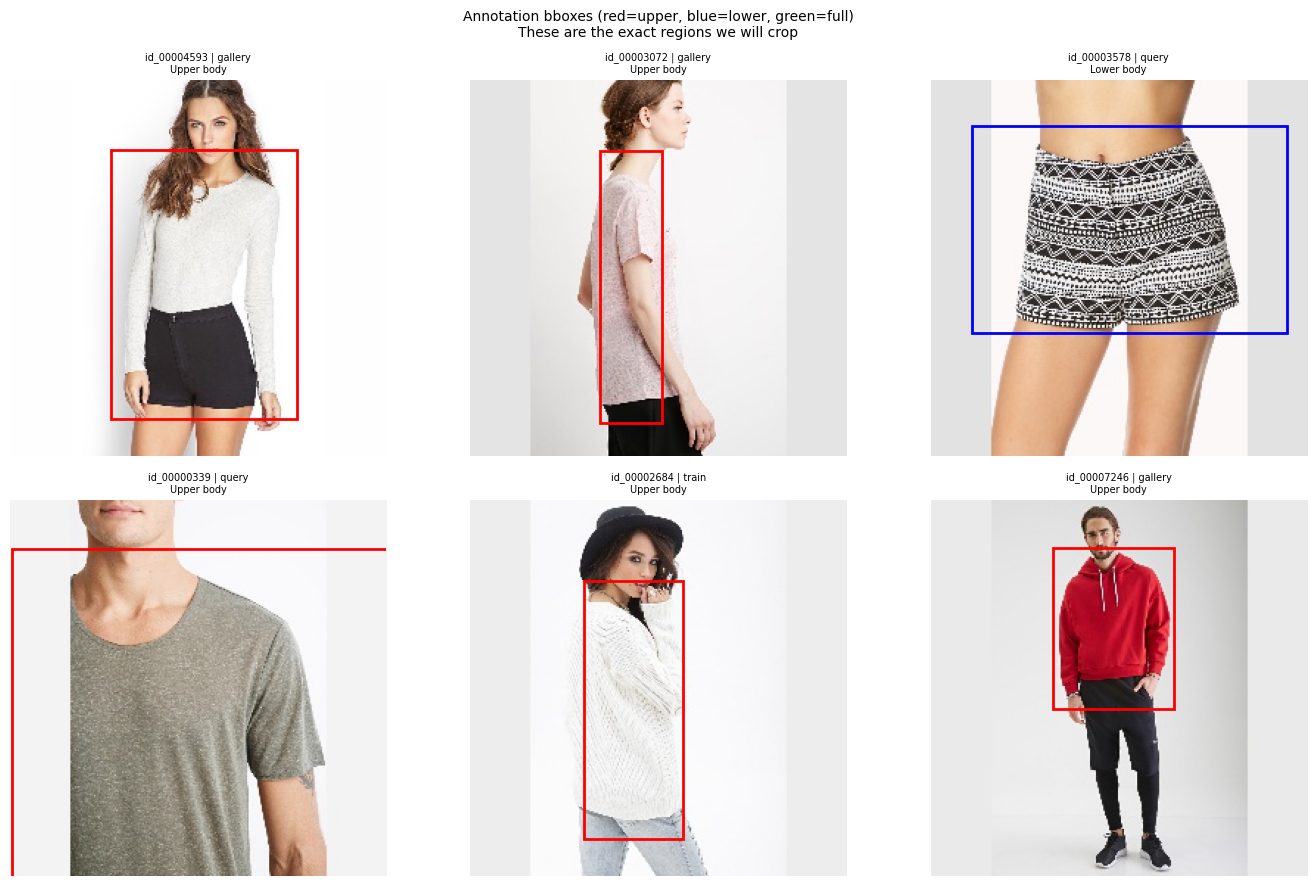

In [5]:
CLOTHES_LABELS = {1: 'Upper body', 2: 'Lower body', 3: 'Full body'}
COLORS         = {1: 'red', 2: 'blue', 3: 'green'}

samples = df.sample(6, random_state=42)

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.flatten()

for i, (_, row) in enumerate(samples.iterrows()):
    img_path = get_full_path(row['image_name'])
    if not os.path.exists(img_path):
        axes[i].axis('off')
        continue
    img = Image.open(img_path).convert('RGB')
    axes[i].imshow(img)
    x1, y1, x2, y2 = row['x1'], row['y1'], row['x2'], row['y2']
    color = COLORS.get(row['clothes_type'], 'red')
    rect  = patches.Rectangle(
        (x1, y1), x2 - x1, y2 - y1,
        linewidth=2, edgecolor=color, facecolor='none'
    )
    axes[i].add_patch(rect)
    label = CLOTHES_LABELS.get(row['clothes_type'], '?')
    axes[i].set_title(f"{row['item_id']} | {row['split']}\n{label}", fontsize=7)
    axes[i].axis('off')

plt.suptitle('Annotation bboxes (red=upper, blue=lower, green=full)\nThese are the exact regions we will crop', fontsize=10)
plt.tight_layout()
plt.show()

## Step 6: Crop All 52k Images Using Annotation BBox

For each image, read annotation bbox from CSV, apply small padding, crop and save.
No YOLO inference needed — just simple PIL crop.
Expected time: **5-8 minutes** for all 52k images. No GPU needed.

In [6]:
crop_paths = []
failed     = []
success    = 0
skipped    = 0

for _, row in tqdm(df.iterrows(), total=len(df), desc='Cropping'):
    src_path  = get_full_path(row['image_name'])
    save_path = get_crop_save_path(row['image_name'])
    crop_paths.append(save_path)

    if os.path.exists(save_path):
        skipped += 1
        continue

    if not os.path.exists(src_path):
        failed.append(row['image_name'])
        continue

    try:
        img = Image.open(src_path).convert('RGB')
        crop_and_save(img, row['x1'], row['y1'], row['x2'], row['y2'], save_path)
        success += 1
    except Exception as e:
        failed.append(row['image_name'])

print(f'Successfully cropped : {success:,}')
print(f'Already existed      : {skipped:,}')
print(f'Failed               : {len(failed):,}')

Cropping: 100%|██████████| 52712/52712 [10:44<00:00, 81.77it/s]

Successfully cropped : 52,712
Already existed      : 0
Failed               : 0


## Step 7: Visualise Crops — Original vs Cropped

The crop should show only the specific clothing item, not the full person.

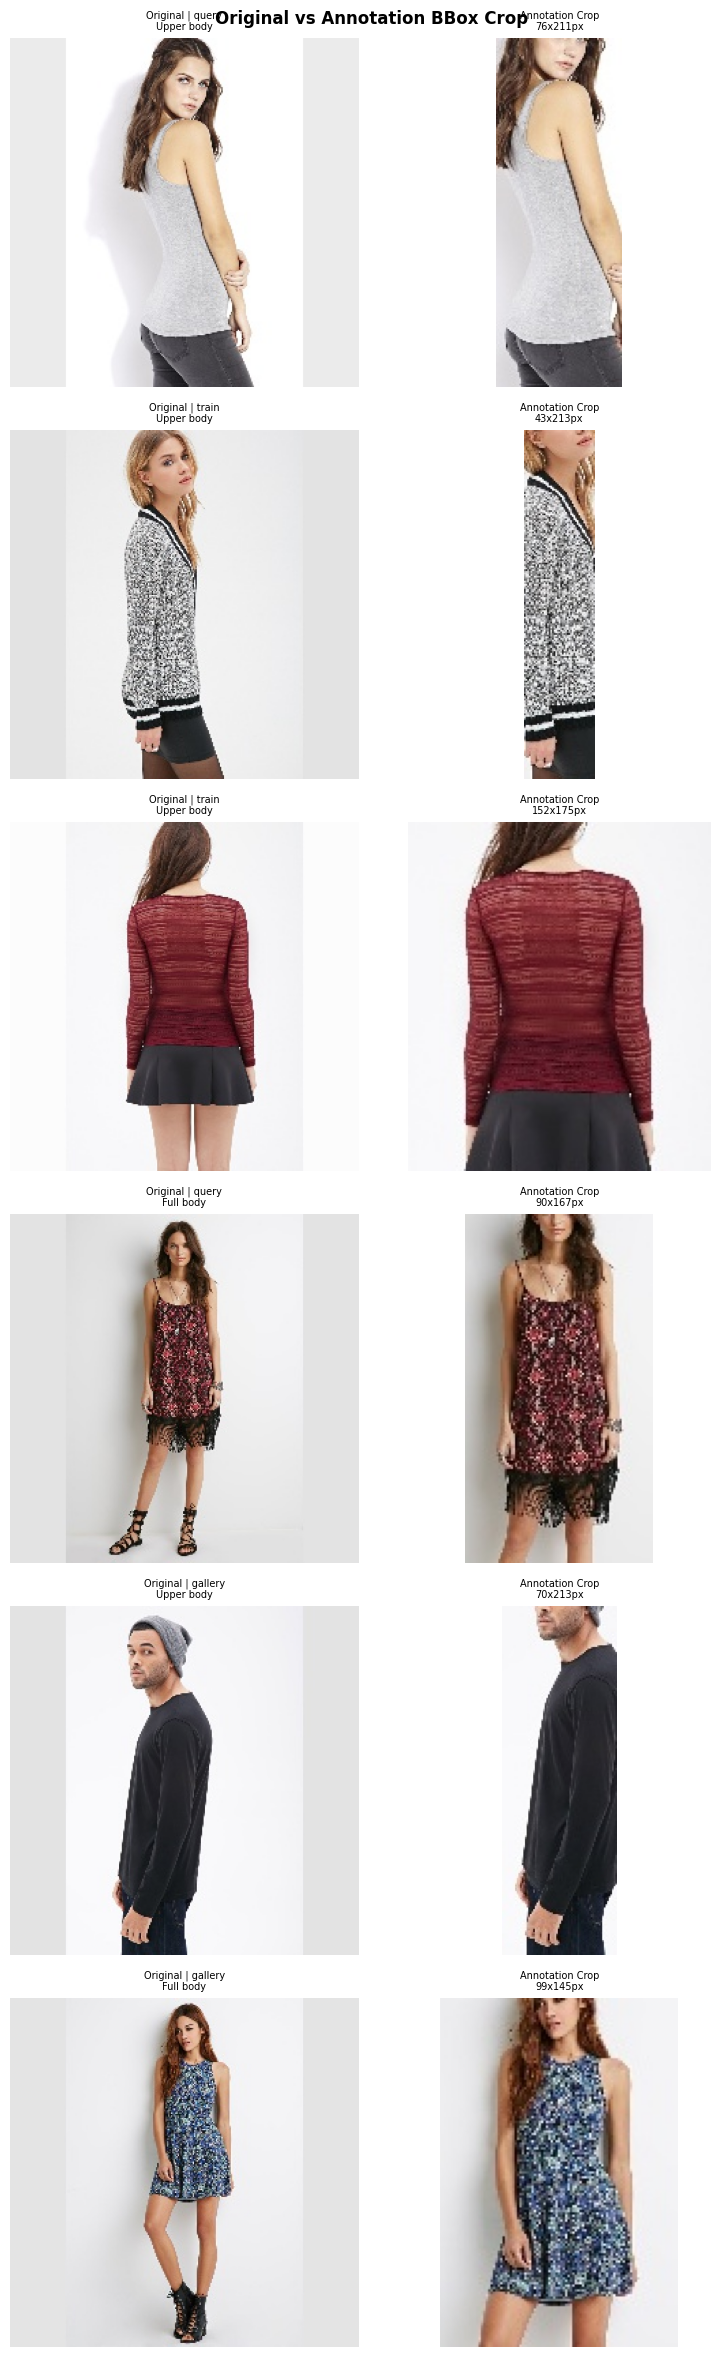

In [7]:
df['crop_path']   = crop_paths
df['crop_exists'] = df['crop_path'].apply(os.path.exists)

samples = df[df['crop_exists']].sample(6, random_state=7)

fig, axes = plt.subplots(6, 2, figsize=(8, 24))

for i, (_, row) in enumerate(samples.iterrows()):
    orig = Image.open(get_full_path(row['image_name'])).convert('RGB')
    crop = Image.open(row['crop_path']).convert('RGB')
    label = CLOTHES_LABELS.get(row['clothes_type'], '?')

    axes[i][0].imshow(orig)
    axes[i][0].set_title(f'Original | {row["split"]}\n{label}', fontsize=7)
    axes[i][0].axis('off')

    axes[i][1].imshow(crop)
    axes[i][1].set_title(f'Annotation Crop\n{crop.size[0]}x{crop.size[1]}px', fontsize=7)
    axes[i][1].axis('off')

plt.suptitle('Original vs Annotation BBox Crop', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 8: Save Output CSVs

In [8]:
df['crop_method'] = 'annotation_bbox'

df.to_csv(os.path.join(OUTPUT_DIR, 'master_crops.csv'), index=False)

for split_name in ['train', 'query', 'gallery']:
    split_df = df[df['split'] == split_name].reset_index(drop=True)
    split_df.to_csv(os.path.join(OUTPUT_DIR, f'{split_name}_crops.csv'), index=False)
    print(f'{split_name}_crops.csv : {len(split_df):,} rows  |  crops on disk: {split_df["crop_exists"].sum():,}')

print(f'\nmaster_crops.csv   : {len(df):,} rows')
print(f'Total crops on disk: {df["crop_exists"].sum():,} / {len(df):,}')

train_crops.csv : 25,882 rows  |  crops on disk: 25,882
query_crops.csv : 14,218 rows  |  crops on disk: 14,218
gallery_crops.csv : 12,612 rows  |  crops on disk: 12,612

master_crops.csv   : 52,712 rows
Total crops on disk: 52,712 / 52,712


## Step 9: Final Summary

In [9]:
print('=' * 55)
print('      ANNOTATION BBOX CROPPING COMPLETE')
print('=' * 55)
print(f'  Crop method          : Annotation BBox (ground truth)')
print(f'  Total images         : {len(df):,}')
print(f'  Successfully cropped : {df["crop_exists"].sum():,}')
print(f'  Failed               : {len(failed):,}')
print(f'  Padding used         : {BBOX_PADDING}px')
print()
print('  Save as new Kaggle dataset:')
print('    master_crops.csv')
print('    train_crops.csv')
print('    query_crops.csv')
print('    gallery_crops.csv')
print('    data/bbox_crops/   <- all cropped images')
print()
print('  Online pipeline (Streamlit):')
print('    User uploaded image -> fine-tuned YOLO -> crop -> CLIP')
print()
print('  Next notebook: BLIP-2 Captioning')
print('=' * 55)

      ANNOTATION BBOX CROPPING COMPLETE
  Crop method          : Annotation BBox (ground truth)
  Total images         : 52,712
  Successfully cropped : 52,712
  Failed               : 0
  Padding used         : 10px

  Save as new Kaggle dataset:
    master_crops.csv
    train_crops.csv
    query_crops.csv
    gallery_crops.csv
    data/bbox_crops/   <- all cropped images

  Online pipeline (Streamlit):
    User uploaded image -> fine-tuned YOLO -> crop -> CLIP

  Next notebook: BLIP-2 Captioning
